<a href="https://colab.research.google.com/github/luverev/Hello-world/blob/main/Clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicción de tipo clasificación**

1. Preparación de Datos
2. División de los datos 70-30
3. Aprendizaje del Modelo
4. Evaluación del Modelo: exactitud
5. Guardar el modelo

El despliegue se realiza en otro jupyter_notebook

In [2]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

**1. Preparación de Datos**

In [4]:
#Cargamos los datos
data = pd.read_excel("/content/datos_limpios.xlsx", sheet_name=0)
data.head()

,Unnamed: 0,Region,Year,Petróleo_t,Gas Natural_t,Carbón_t,Energía Hidroeléctrica_t,Energías Renovables_t,Energías Renovables_t+1,Nivel transicion energetica_t+1
0,0,North America,2022,4.306535,4.457286,0.385116,3.732924,0.636991,0.676281,"Medio_0,51-5"
1,1,North America,2022,3.774268,3.274093,0.244213,0.333744,0.459067,0.537013,"Medio_0,51-5"
2,2,North America,2022,35.750114,31.665119,9.910711,2.358374,8.416627,8.779252,Alto_5
3,3,Cent. America,2022,1.482501,1.650702,0.053610,0.213708,0.237979,0.238107,Bajo_0.0-0.5
4,4,Cent. America,2022,5.006519,1.151554,0.585582,4.008753,2.552388,2.974078,"Medio_0,51-5"


In [5]:
#Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       137 non-null    int64  
 1   Region                           137 non-null    object 
 2   Year                             137 non-null    int64  
 3   Petróleo_t                       137 non-null    float64
 4   Gas Natural_t                    137 non-null    float64
 5   Carbón_t                         137 non-null    float64
 6   Energía Hidroeléctrica_t         137 non-null    float64
 7   Energías Renovables_t            137 non-null    float64
 8   Energías Renovables_t+1          137 non-null    float64
 9   Nivel transicion energetica_t+1  137 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 10.8+ KB


In [6]:
#Corrección tipos de datos
data['Region']=data['Region'].astype('category')
data['Year']=data['Year'].astype('category')
data['Nivel transicion energetica_t+1']=data['Nivel transicion energetica_t+1'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Unnamed: 0                       137 non-null    int64   
 1   Region                           137 non-null    category
 2   Year                             137 non-null    category
 3   Petróleo_t                       137 non-null    float64 
 4   Gas Natural_t                    137 non-null    float64 
 5   Carbón_t                         137 non-null    float64 
 6   Energía Hidroeléctrica_t         137 non-null    float64 
 7   Energías Renovables_t            137 non-null    float64 
 8   Energías Renovables_t+1          137 non-null    float64 
 9   Nivel transicion energetica_t+1  137 non-null    category
dtypes: category(3), float64(6), int64(1)
memory usage: 8.6 KB


In [7]:
#Eliminamos variables irrelevantes para el modelo predictivo

data = data.drop(columns='Unnamed: 0') # Id de fila irrelevante
data = data.drop(columns='Energías Renovables_t+1') # Se desea predecir como categoría y no como número
data = data.drop(columns='Year') # Year no representa una característica energética del país sino una referencia temporal
data.head()

,Region,Petróleo_t,Gas Natural_t,Carbón_t,Energía Hidroeléctrica_t,Energías Renovables_t,Nivel transicion energetica_t+1
0,North America,4.306535,4.457286,0.385116,3.732924,0.636991,"Medio_0,51-5"
1,North America,3.774268,3.274093,0.244213,0.333744,0.459067,"Medio_0,51-5"
2,North America,35.750114,31.665119,9.910711,2.358374,8.416627,Alto_5
3,Cent. America,1.482501,1.650702,0.053610,0.213708,0.237979,Bajo_0.0-0.5
4,Cent. America,5.006519,1.151554,0.585582,4.008753,2.552388,"Medio_0,51-5"


<Axes: >

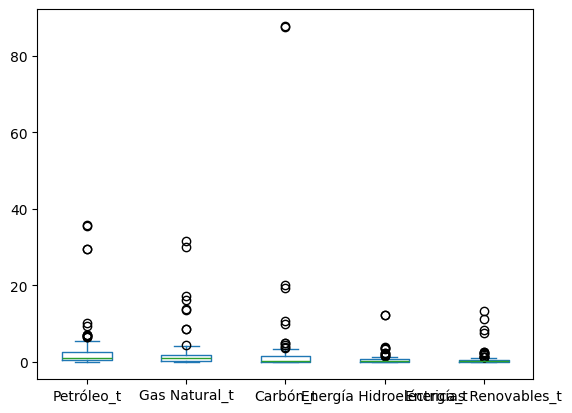

In [8]:
# Descripción d evariables númericas
data.plot(kind='box')

<Axes: xlabel='Region'>

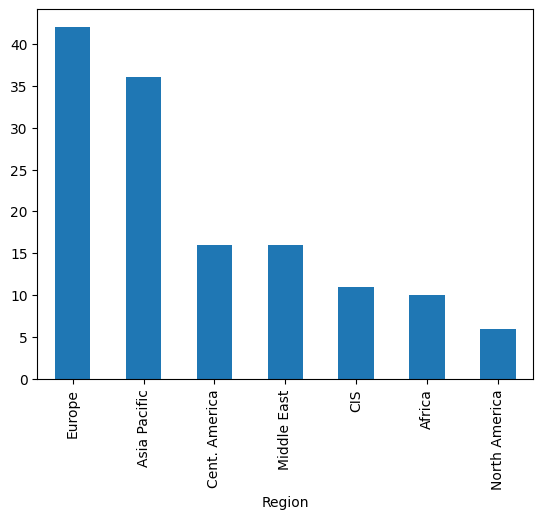

In [9]:
data['Region'].value_counts().plot(kind='bar')

<Axes: xlabel='Nivel transicion energetica_t+1'>

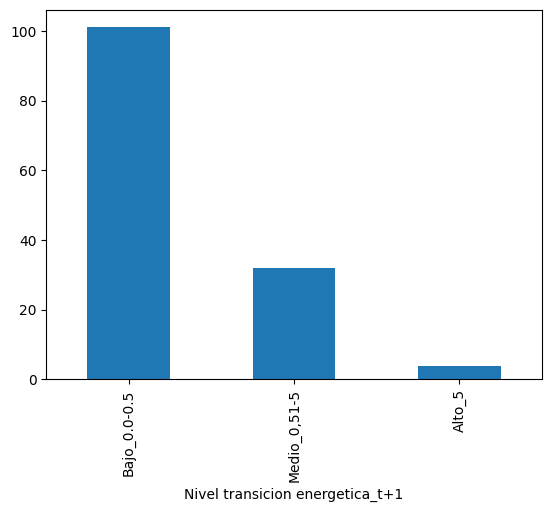

In [10]:
# Descripción variable objetivo
data['Nivel transicion energetica_t+1'].value_counts().plot(kind='bar')


 Recordar que a la variable objetivo no se le crean Dummies, esto solo se hace para las variables predictoras, pero a la variale objetivo si se le puede hacer Balanceo, investigar como se hace esto, la tecnica de balanceo solo se aplica cuando la variable objetivo es categorica.

**Transformaciones**

In [11]:
#Dummies para las variables predictoras categóricas
data = pd.get_dummies(data, columns=['Region'], drop_first=False, dtype=int)

data.head()

,Petróleo_t,Gas Natural_t,Carbón_t,Energía Hidroeléctrica_t,Energías Renovables_t,Nivel transicion energetica_t+1,Region_Africa,Region_Asia Pacific,Region_CIS,Region_Cent. America,Region_Europe,Region_Middle East,Region_North America
0,4.306535,4.457286,0.385116,3.732924,0.636991,"Medio_0,51-5",0,0,0,0,0,0,1
1,3.774268,3.274093,0.244213,0.333744,0.459067,"Medio_0,51-5",0,0,0,0,0,0,1
2,35.750114,31.665119,9.910711,2.358374,8.416627,Alto_5,0,0,0,0,0,0,1
3,1.482501,1.650702,0.053610,0.213708,0.237979,Bajo_0.0-0.5,0,0,0,1,0,0,0
4,5.006519,1.151554,0.585582,4.008753,2.552388,"Medio_0,51-5",0,0,0,1,0,0,0


**2. División 70-30**

<Axes: xlabel='Nivel transicion energetica_t+1'>

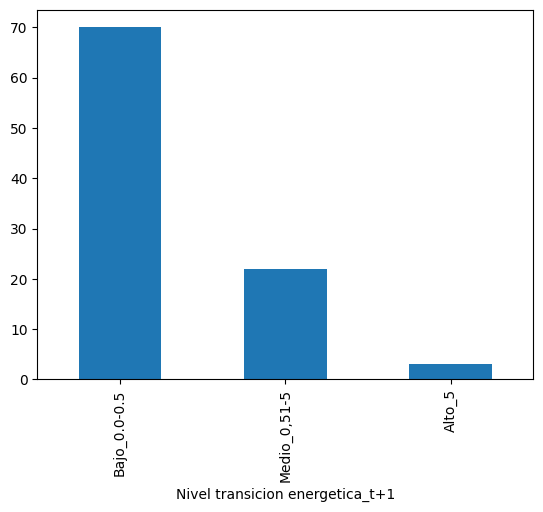

In [12]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("Nivel transicion energetica_t+1", axis = 1) # Variables predictoras (drop borro la variable objetivo)
Y = data['Nivel transicion energetica_t+1'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado
Y_train.value_counts().plot(kind='bar') # variable objetivo del 70%

<Axes: xlabel='Nivel transicion energetica_t+1'>

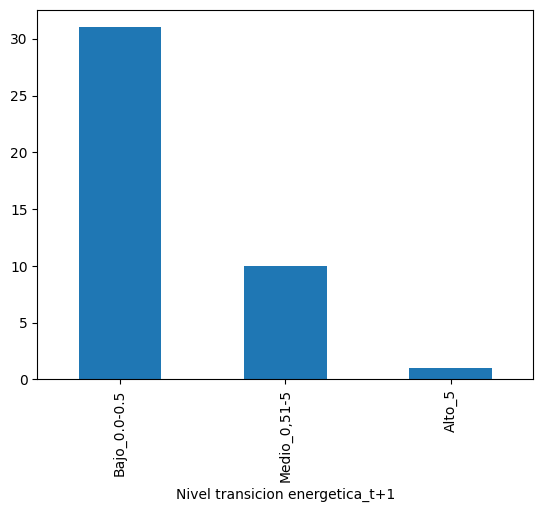

In [13]:
# variable objetivo del 30%
Y_test.value_counts().plot(kind='bar')


**3. Aprendizaje con el 70% y Evaluación con el 30%**

**Tree**

No se normaliza para tener explicabilidad

In [14]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeClassifier #DecisionTreeRegressor

modelTree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=2, max_depth=20) #gini, entropy
modelTree.fit(X_train, Y_train) #70% train

DecisionTreeClassifier(max_depth=20, min_samples_leaf=2)

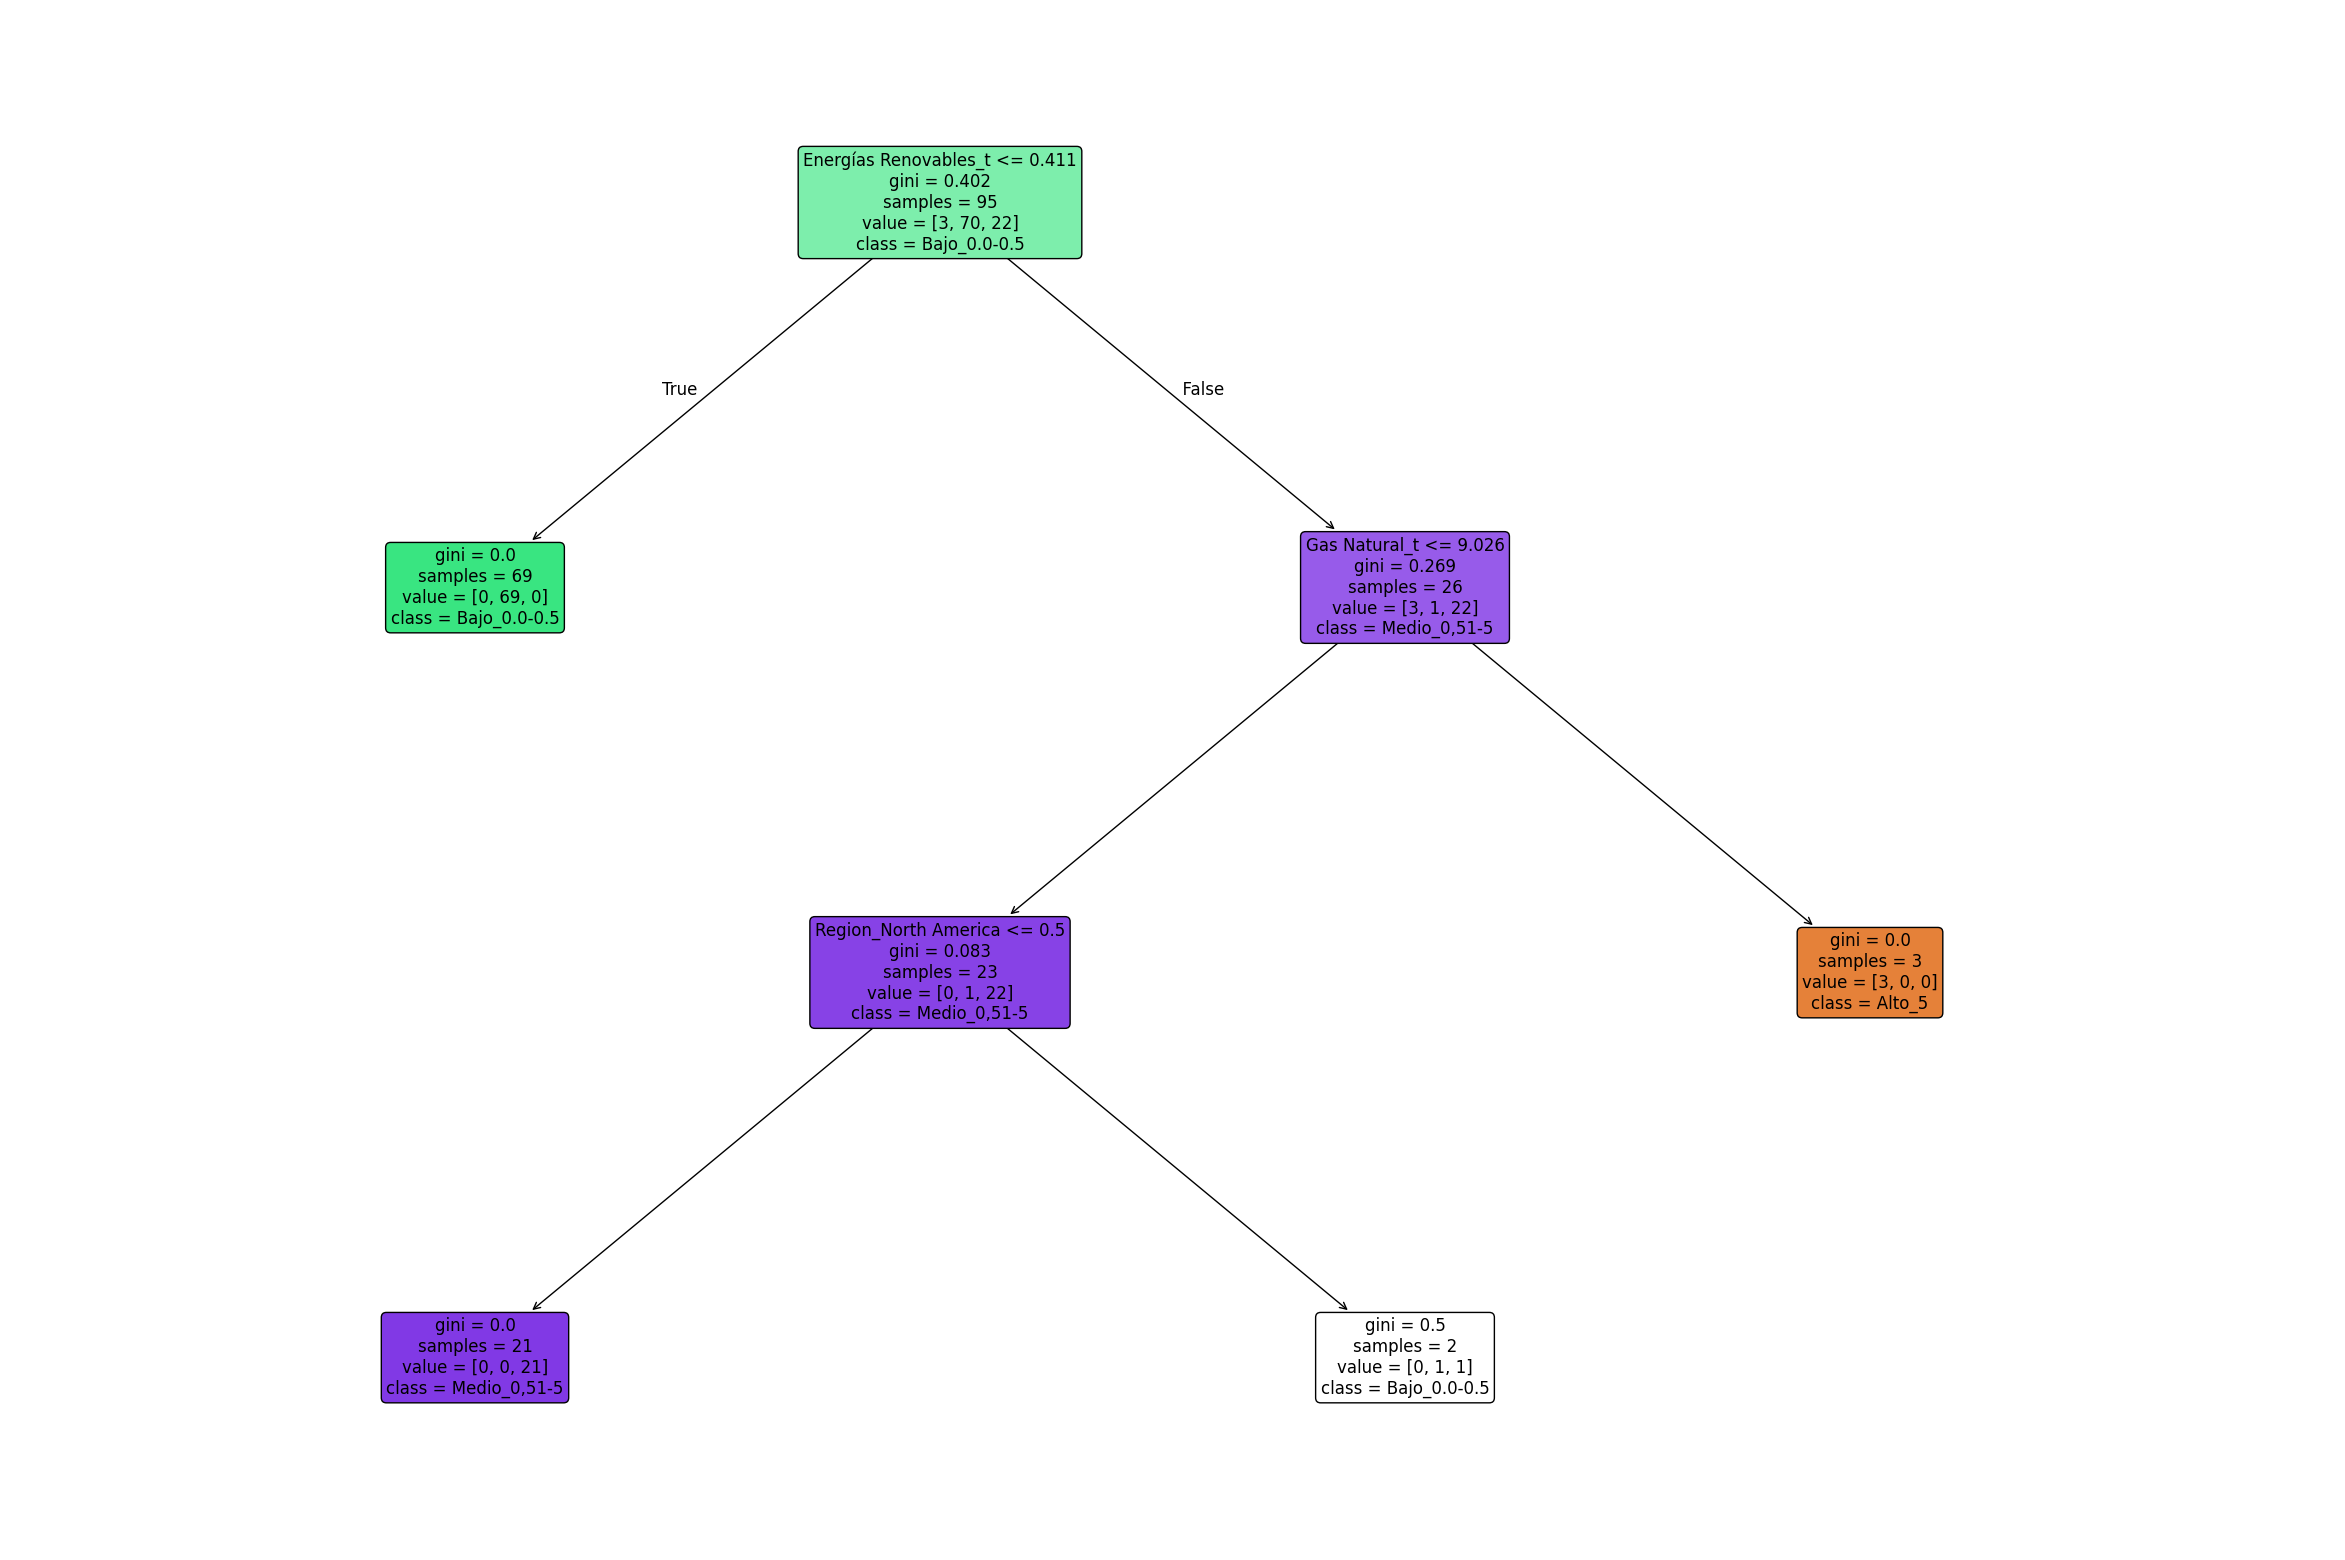

In [15]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20)) #Tamaño de la imagen
plot_tree(modelTree, feature_names=X_train.columns.values, class_names=modelTree.classes_, rounded=True,  fontsize=12, filled=True)
plt.show()

In [16]:
#Evaluación 30% (X_test)
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30% Test
print(Y_pred)

['Medio_0,51-5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Medio_0,51-5'
 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5'
 'Medio_0,51-5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5'
 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5'
 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Medio_0,51-5' 'Bajo_0.0-0.5'
 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5'
 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5'
 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Medio_0,51-5' 'Medio_0,51-5'
 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Medio_0,51-5' 'Alto_5'
 'Medio_0,51-5' 'Bajo_0.0-0.5' 'Bajo_0.0-0.5' 'Medio_0,51-5'
 'Bajo_0.0-0.5']


In [17]:
#Exactitud: Correctos/Total
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.9285714285714286


**Random Forest**

tambien existe otro metodo (XGBoost) basado en arboles muy utilizado en Machine learning

In [18]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=100,  max_samples=0.9, criterion='gini',
                              max_depth=20, min_samples_leaf=2)
model_rf.fit(X_train, Y_train) #70%

RandomForestClassifier(max_depth=20, max_samples=0.9, min_samples_leaf=2)

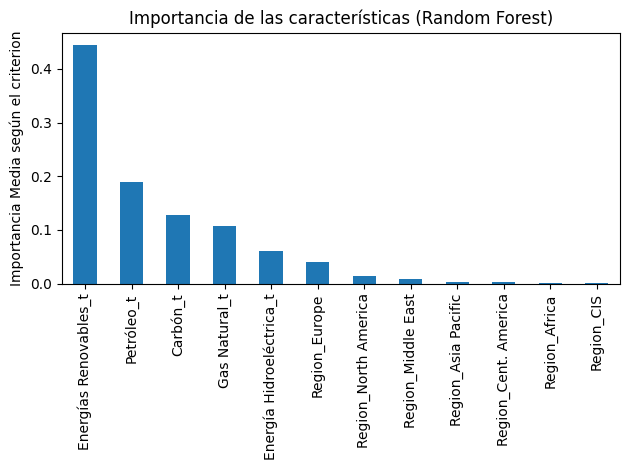

In [19]:
#Importancia de las características
importances = model_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Importancia de las características (Random Forest)")
ax.set_ylabel("Importancia Media según el criterion")
fig.tight_layout()
plt.show()

In [20]:
#Evaluación de RandomForest con 30%
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Exactitud: Correctos/Total
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.9761904761904762


**KNN**

Es necesario normalización

In [21]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_numericas=['Petróleo_t','Gas Natural_t','Carbón_t','Energía Hidroeléctrica_t','Energías Renovables_t']

min_max_scaler.fit(data[variables_numericas]) #Ajuste de los parametros sobre 100% de los datos (data): max - min

#Se aplica la normalización a 70%  y 30%
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas]) #70%
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas]) #30%
X_train.head()

,Petróleo_t,Gas Natural_t,Carbón_t,Energía Hidroeléctrica_t,Energías Renovables_t,Region_Africa,Region_Asia Pacific,Region_CIS,Region_Cent. America,Region_Europe,Region_Middle East,Region_North America
43,0.042820,0.068886,0.000502,0.010184,0.007651,1,0,0,0,0,0,0
23,0.012729,0.011041,0.001723,0.010712,0.008183,0,0,0,0,1,0,0
87,0.010644,0.004793,0.000401,0.110226,0.009823,0,0,0,0,1,0,0
9,0.071525,0.011217,0.001895,0.067145,0.025329,0,0,0,1,0,0,0
109,0.011163,0.031796,0.000040,0.000000,0.000674,0,0,0,0,0,1,0


In [22]:
#Aprendizaje KNN con 70%
from sklearn.neighbors  import KNeighborsClassifier #KNeighborsRegressor

modelKnn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')#euclidean, minkowski
modelKnn.fit(X_train, Y_train) #70%

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

In [23]:
#Evaluación de Knn con 30%
from sklearn import metrics

Y_pred = modelKnn.predict(X_test) #30%

#Exactitud: Correctos/Total
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.9761904761904762


**4. Guardamos el mejor modelo**

Selecion del modelo:
1. Calidad de los modelos
2. Complejidad computacional: Tree mas liviano computacionalmente

In [24]:
#Selección del modelo final, en este caso selccione el modelo Knn
modelo_final=modelKnn

Se entrena modelo final con 100% de los datos (X,Y)

In [25]:
# Si selecciona Knn -> se debe normalzar X (100% de los datos)
# Si selecciona Tree o RF no se normaliza y se comenta la siguiente línea
X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

In [26]:
#Entrenamos modelo final
modelo_final.fit(X, Y) #100%

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

In [27]:
import pickle
filename = 'modelo-class.pkl'
variables= X.columns._values
pickle.dump([modelo_final,min_max_scaler,variables], open(filename, 'wb'))